In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import os

plt.style.use('ggplot')

Part-A

1.

In [137]:
fg_df = pd.read_csv("data/fear_greed_index.csv")
hist_df = pd.read_csv("data/historical_data.csv")

print(f"Fear/Greed Data Shape: {fg_df.shape[0]} rows, {fg_df.shape[1]} columns")
print(f"Historical Data Shape: {hist_df.shape[0]} rows, {hist_df.shape[1]} columns")

Fear/Greed Data Shape: 2644 rows, 4 columns
Historical Data Shape: 211224 rows, 16 columns


In [138]:
print("--- Missing Values ---")
print("Fear/Greed Data:\n", fg_df.isnull().sum().to_dict())
print("\nHistorical Data:\n", hist_df.isnull().sum().to_dict())

print("\n--- Duplicates ---")
print("Fear/Greed Data Duplicates:", fg_df.duplicated().sum())
print("Historical Data Duplicates:", hist_df.duplicated().sum())

Historical Data Duplicates: 0


2.

In [139]:
hist_df['date'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date.astype(str)

In [140]:
def simplify_sentiment(c):
    c = str(c).lower()
    if 'fear' in c: return 'Fear'
    if 'greed' in c: return 'Greed'
    return 'Neutral'

fg_df['sentiment'] = fg_df['classification'].apply(simplify_sentiment)

In [141]:
merged_df = pd.merge(hist_df, fg_df[['date', 'value', 'classification', 'sentiment']], on='date', how='inner')

3.

In [142]:
def calc_win_rate(pnl_series):
    wins = (pnl_series > 0).sum()
    total_closed = (pnl_series != 0).sum()
    return wins / total_closed if total_closed > 0 else 0

In [143]:
daily_metrics = merged_df.groupby(['date', 'Account', 'sentiment']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    long_trades=('Side', lambda x: (x.str.upper() == 'BUY').sum()),
    short_trades=('Side', lambda x: (x.str.upper() == 'SELL').sum()),
    win_rate=('Closed PnL', calc_win_rate)
).reset_index()

In [144]:
daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / (daily_metrics['short_trades'] + 1e-9)

In [145]:
daily_metrics.to_csv('data/daily_metrics.csv', index=False)

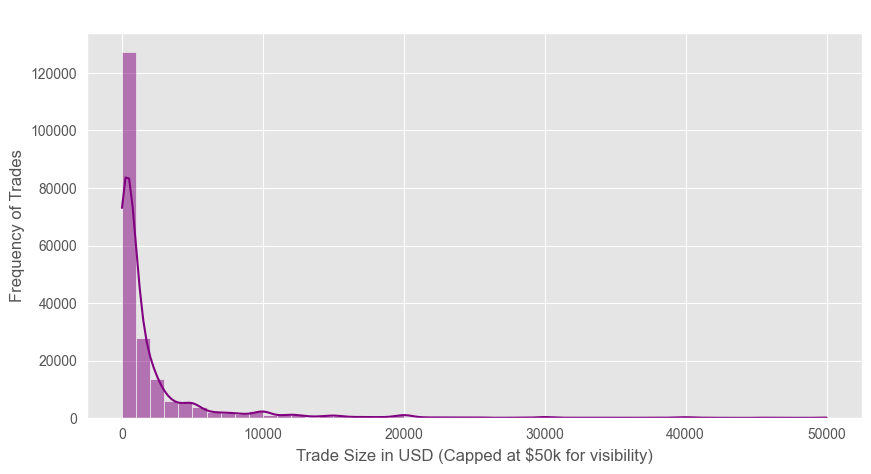

In [146]:
plt.figure(figsize=(10, 5))
sns.histplot(hist_df[hist_df['Size USD'] < 50000]['Size USD'], bins=50, kde=True, color='purple')
plt.title('Distribution of Trade Sizes (USD) - Risk/Exposure Proxy')
plt.xlabel('Trade Size in USD (Capped at $50k for visibility)')
plt.ylabel('Frequency of Trades')
plt.show()

Part-B

1. and 2.

In [147]:
perf_by_sentiment = daily_metrics.groupby('sentiment').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean')
).reset_index()
print("--- Performance by Sentiment ---")
print(perf_by_sentiment)

--- Performance by Sentiment ---
  sentiment  avg_daily_pnl  median_daily_pnl  avg_win_rate  avg_trades  \
0      Fear    5185.146443        122.737038      0.609863  105.363291   
1     Greed    4144.208334        265.247725      0.615607   76.912266   
2   Neutral    3438.618818        167.551743      0.613455  100.228723   

   avg_trade_size  
0     8529.859802  
1     5954.632633  
2     6963.694861  


3.

In [148]:
account_stats = daily_metrics.groupby('Account').agg(
    total_trades=('num_trades', 'sum'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()

In [149]:
median_trades = account_stats['total_trades'].median()
account_stats['Freq_Segment'] = np.where(account_stats['total_trades'] >= median_trades, 'Frequent', 'Infrequent')

In [150]:
median_win_rate = account_stats['avg_win_rate'].median()
account_stats['Win_Segment'] = np.where(account_stats['avg_win_rate'] >= median_win_rate, 'High Win Rate', 'Low Win Rate')

In [151]:
daily_metrics = pd.merge(daily_metrics, account_stats[['Account', 'Freq_Segment', 'Win_Segment']], on='Account', how='left')

In [152]:
segment_analysis_win = daily_metrics.groupby(['Win_Segment', 'sentiment']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean')
).reset_index()
print("\n--- Segment Analysis (Win Rate Archetypes) ---")
print(segment_analysis_win)


--- Segment Analysis (Win Rate Archetypes) ---
     Win_Segment sentiment      avg_pnl  avg_trade_size
0  High Win Rate      Fear  5930.236591     9175.602120
1  High Win Rate     Greed  2689.174220     6401.449812
2  High Win Rate   Neutral  1636.908909     6996.492785
3   Low Win Rate      Fear  4006.637844     7508.489601
4   Low Win Rate     Greed  6875.963556     5115.755281
5   Low Win Rate   Neutral  6692.453132     6904.462789


4.

Performance Overview

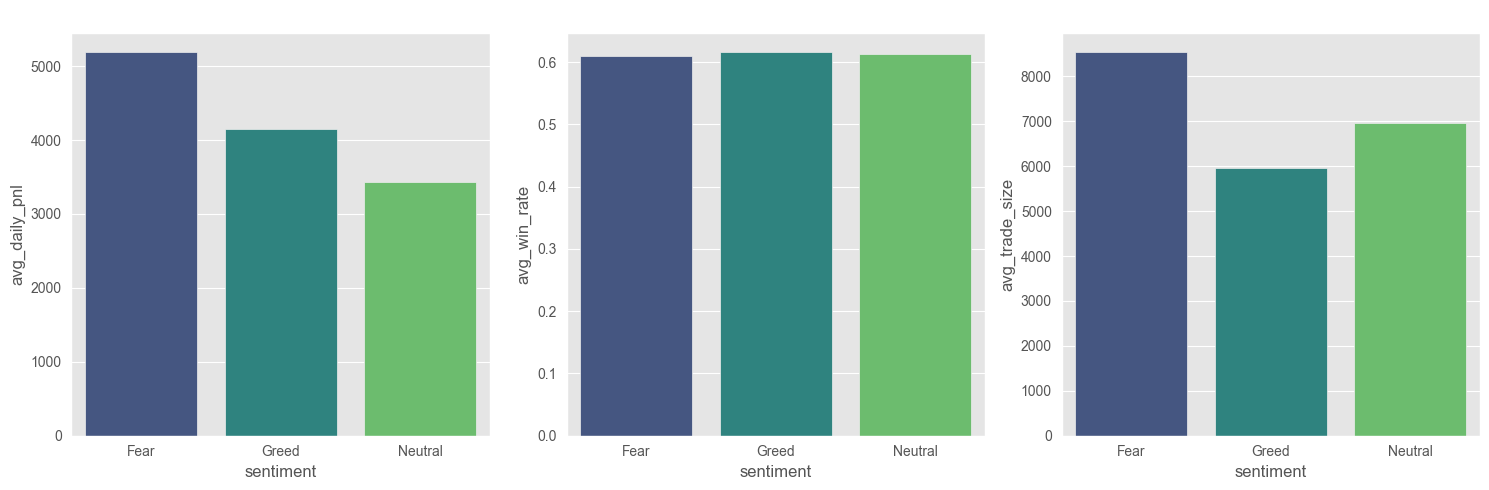

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=perf_by_sentiment, x='sentiment', y='avg_daily_pnl', ax=axes[0], palette='viridis')
axes[0].set_title('Average Daily PnL per Sentiment')
sns.barplot(data=perf_by_sentiment, x='sentiment', y='avg_win_rate', ax=axes[1], palette='viridis')
axes[1].set_title('Average Win Rate per Sentiment')
sns.barplot(data=perf_by_sentiment, x='sentiment', y='avg_trade_size', ax=axes[2], palette='viridis')
axes[2].set_title('Average Trade Size (USD) per Sentiment')
plt.tight_layout()
plt.savefig('sentiment_performance.png')

Behavior based on sentiment

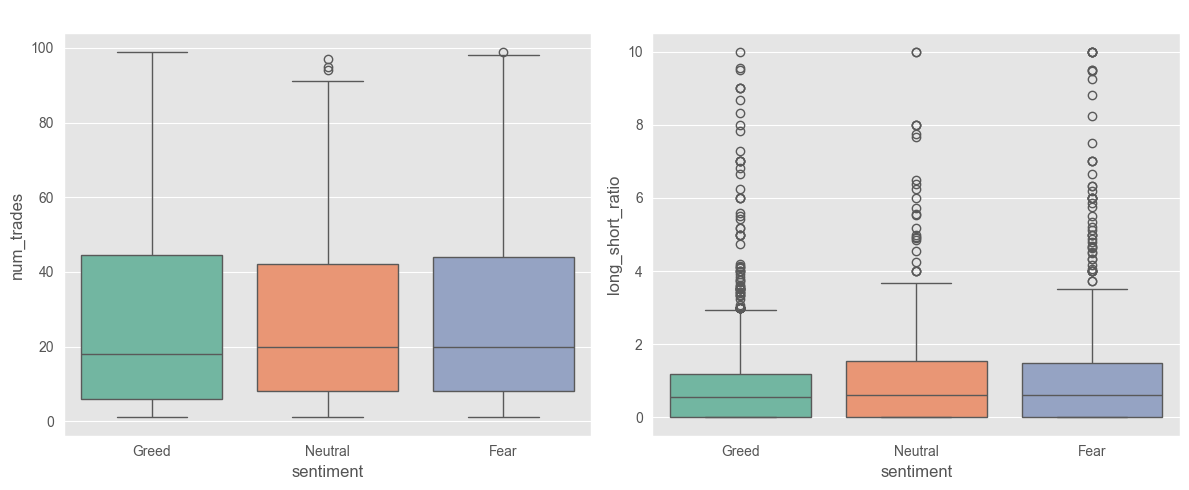

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=daily_metrics[daily_metrics['num_trades'] < 100], x='sentiment', y='num_trades', ax=axes[0], palette='Set2')
axes[0].set_title('Trade Frequency by Sentiment (Capped at 100)')
ls_ratio_capped = daily_metrics[daily_metrics['long_short_ratio'] < 10]
sns.boxplot(data=ls_ratio_capped, x='sentiment', y='long_short_ratio', ax=axes[1], palette='Set2')
axes[1].set_title('Long/Short Ratio by Sentiment')
plt.tight_layout()
plt.savefig('sentiment_behavior.png')

Archetype Segments

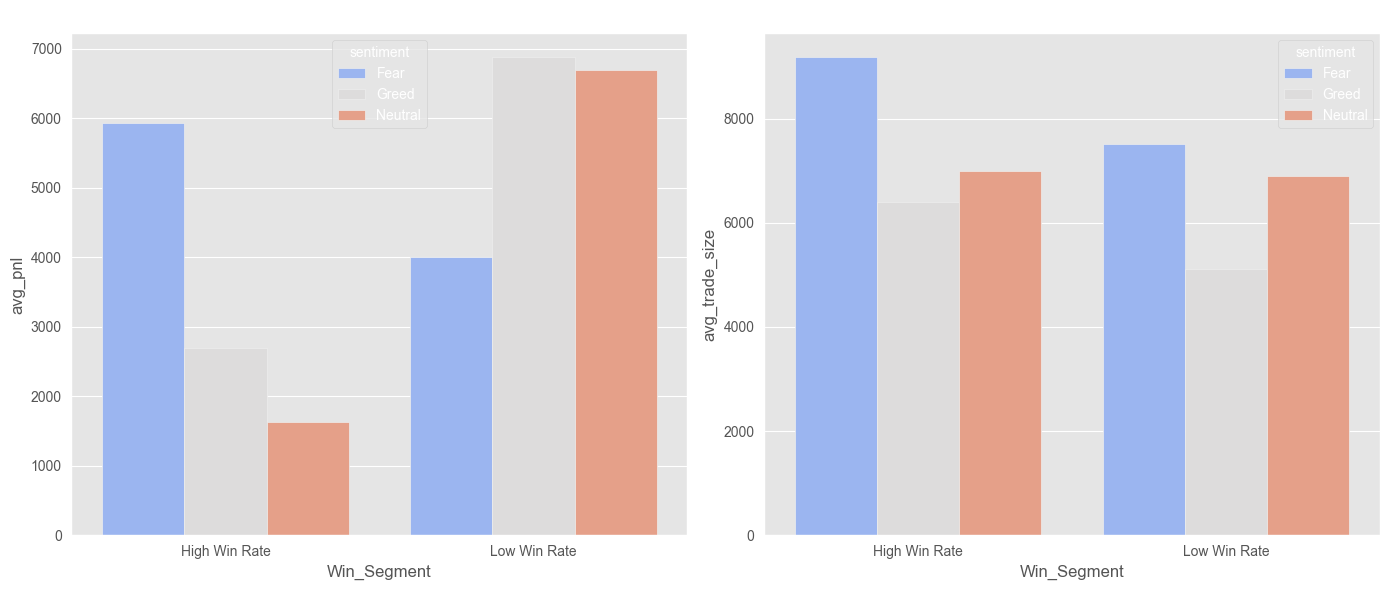

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=segment_analysis_win, x='Win_Segment', y='avg_pnl', hue='sentiment', ax=axes[0], palette='coolwarm')
axes[0].set_title('Avg Daily PnL by Trader Segment & Sentiment')
sns.barplot(data=segment_analysis_win, x='Win_Segment', y='avg_trade_size', hue='sentiment', ax=axes[1], palette='coolwarm')
axes[1].set_title('Avg Trade Size by Trader Segment & Sentiment')
plt.tight_layout()
plt.savefig('segment_behavior.png')

Part-C

1. Reduce leverage for inconsistent traders during "Fear" days

The Idea:
During Fear days, the platform should automatically lower the maximum leverage or position size limits for the "Low Win Rate" trader segment.

Why:
The data shows that during high-volatility Fear days, inconsistent traders actually try to increase their average trade sizes, but they just end up losing more money. By capping their leverage, the platform protects them from blowing up their accounts. At the same time, we can leave the limits alone for the "High Win Rate" segment, because the data proves they actually capitalize on the Fear volatility and bring in higher profits.

2. Incentivize frequent traders to provide liquidity during "Greed" days

The Idea:
When the market shifts to Greed, offer temporary maker-rebates or lower fees for the "Frequent" trader segment to encourage them to place limit orders.

Why:
I noticed in the data that overall trading frequency drops pretty significantly across the board when the market is in Greed (likely because people are just holding onto their winning momentum positions instead of actively trading). To make sure the order books stay thick during these slower periods, we should give our most active users a financial reason to keep making trades.

Bonus

Simple Predictive Model

In [156]:
df_ml = daily_metrics.copy()
df_ml['date'] = pd.to_datetime(df_ml['date'])
df_ml = df_ml.sort_values(['Account', 'date'])

In [157]:
df_ml['next_day_pnl'] = df_ml.groupby('Account')['daily_pnl'].shift(-1)

In [158]:
df_ml = df_ml.dropna(subset=['next_day_pnl']).copy()

In [159]:
df_ml['target_profitable'] = (df_ml['next_day_pnl'] > 0).astype(int)

In [160]:
df_ml = pd.get_dummies(df_ml, columns=['sentiment'], drop_first=True)

In [161]:
feature_cols = ['daily_pnl', 'num_trades', 'avg_trade_size', 'win_rate'] + \
               [c for c in df_ml.columns if 'sentiment_' in c]

X = df_ml[feature_cols].fillna(0)
y = df_ml['target_profitable']

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [163]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
accuracy = rf.score(X_test, y_test)
print(f"Accuracy predicting next-day profitability: {accuracy * 100:.1f}%")

Accuracy predicting next-day profitability: 67.5%


In [165]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nMost important features for predicting tomorrow's success:")
print(importances.round(4))


Most important features for predicting tomorrow's success:
daily_pnl            0.2992
win_rate             0.2537
num_trades           0.2269
avg_trade_size       0.1903
sentiment_Neutral    0.0150
sentiment_Greed      0.0149
dtype: float64


Clustering Traders

In [166]:
trader_profiles = daily_metrics.groupby('Account').agg(
    avg_trade_size=('avg_trade_size', 'mean'),
    total_trades=('num_trades', 'sum'),
    avg_win_rate=('win_rate', 'mean')
).fillna(0).reset_index()

In [167]:
scaler = StandardScaler()
features_to_scale = ['avg_trade_size', 'total_trades', 'avg_win_rate']
X_scaled = scaler.fit_transform(trader_profiles[features_to_scale])

In [168]:
kmeans = KMeans(n_clusters=3, random_state=42)
trader_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

In [169]:
def name_cluster(row):
    if row['total_trades'] > 10000: return "High-Frequency Scalper"
    if row['avg_trade_size'] > 15000: return "Whale / Swing Trader"
    return "Retail / Casual Trader"

In [170]:
cluster_summary = trader_profiles.groupby('Cluster').mean(numeric_only=True)
cluster_summary['Account Count'] = trader_profiles.groupby('Cluster').size()
cluster_summary['Archetype'] = cluster_summary.apply(name_cluster, axis=1)
print(cluster_summary[['Archetype', 'Account Count', 'avg_trade_size', 'total_trades', 'avg_win_rate']])

                      Archetype  Account Count  avg_trade_size  total_trades  \
Cluster                                                                        
0          Whale / Swing Trader              8    22205.958577   5095.500000   
1        High-Frequency Scalper              9     2200.658746  15741.555556   
2        Retail / Casual Trader             15     5636.411398   1918.666667   

         avg_win_rate  
Cluster                
0            0.631965  
1            0.748417  
2            0.414415  


In [171]:
os.makedirs('models', exist_ok=True)

joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

joblib.dump(rf, 'models/rf_model.pkl')

print("Models successfully saved to the 'models/' directory")

Models successfully saved to the 'models/' directory
